In [ ]:
import requests
import json
from pathlib import Path
from dotenv import load_dotenv
import os

BASE_DIR = Path.cwd()

load_dotenv()
API_KEY = os.getenv("TMDB_API_KEY")


BASE_URL = "https://api.themoviedb.org/3"
IMAGE_BASE_URL = "https://image.tmdb.org/t/p/w500"


def get_genres():
    url = f"{BASE_URL}/genre/movie/list"
    params = {
        "api_key":API_KEY,
        "language":"ko-KR"
    }
    res = requests.get(url, params=params)
    res.raise_for_status()
    data = res.json()

    return {g["id"]: g["name"] for g in data["genres"]}


# 장르별로 100개의 영화 가져와서 리스트 안에 [영화1, 영화2, ... , 영화100]을 뱉어낼 예정.
# 이걸 for 루프 안에 get_genre()에서 뽑아온 장르의 key를 하나씩 넣으면 각 장르별로 100개의 영화 가져올 수 있음

def get_movie_list_by_genres(genre_id, pages=5, min_votes = 50 ):
    url = f"{BASE_URL}/discover/movie"
    movies = []
    # movies 안에 페이지를 1~15, 100개의 영화 데이터를 vote수대로 차례로 넣으면, 어느정도 인지도가 있는 영화만 나옴.
    for page in range(1,pages+1):
        params = {
            "api_key":API_KEY,
            "language":"ko-KR",
            "with_genres":genre_id,
            "vote_count.gte":min_votes, # 최소 50표 이상 받은 영화만 가져올 예정.
            "sort_by": "vote_count.desc",
            "page":page
        }
        res = requests.get(url,params=params)
        res.raise_for_status()
        # extend([]) : 기존 리스트에 리스트 추가
        movies.extend(res.json()["results"])

    return movies

def collect_movies(pages = 5, min_votes = 50):
    genres = get_genres()
    all_movies = []
    seen = set()
    for genre_id, genre_name in genres.items():
        movies = get_movie_list_by_genres(genre_id=genre_id,pages=pages,min_votes=min_votes)
        for movie in movies:
            if movie['id'] in seen:
                continue
            else:
                all_movies.append(movie)
                seen.add(movie['id'])
        print(genre_name,"추출완료")
        
    return all_movies


def main():
    pass


if __name__=="__main__":
    all_movies = collect_movies()
    print(len(all_movies))
    

액션 추출완료
모험 추출완료
애니메이션 추출완료
코미디 추출완료
범죄 추출완료
다큐멘터리 추출완료
드라마 추출완료
가족 추출완료
판타지 추출완료
역사 추출완료
공포 추출완료
음악 추출완료
미스터리 추출완료
로맨스 추출완료
SF 추출완료
TV 영화 추출완료
스릴러 추출완료
전쟁 추출완료
서부 추출완료
1200


In [18]:
# 가공 단계용 import
import pandas as pd

SAVE_DIR = BASE_DIR / "data"
SAVE_DIR.mkdir(exist_ok=True)

In [19]:
df = pd.DataFrame(all_movies)
movie_df = (df[["id","title","release_date","vote_average","vote_count","popularity"]]
            .rename(columns={"id":"movie_id"})
            .drop_duplicates(subset="movie_id")
            ) 
# .drop_duplicates()로 유일성 보장해주기
movie_df


,movie_id,title,release_date,vote_average,vote_count,popularity
0,27205,인셉션,2010-07-15,8.372,40069,52.8718
1,24428,어벤져스,2012-04-25,8.073,39563,78.0689
2,155,다크 나이트,2008-07-16,8.534,36586,60.9409
3,19995,아바타,2009-12-16,7.609,34578,41.9692
4,293660,데드풀,2016-02-09,7.625,33227,27.8876
...,...,...,...,...,...,...
1195,12146,실종,2003-11-26,6.303,709,5.1333
1196,3110,셰인,1953-04-23,7.327,707,4.5911
1197,11916,호건과 사라,1970-03-02,6.956,700,6.0251
1198,932086,호라이즌: 아메리칸 사가 챕터 1,2024-06-26,6.800,695,5.8097


In [20]:
genres = get_genres()
genres_df = pd.DataFrame(list(genres.items()), columns=["genre_id","genre_name"])
genres_df

,genre_id,genre_name
0,28,액션
1,12,모험
2,16,애니메이션
3,35,코미디
4,80,범죄
5,99,다큐멘터리
6,18,드라마
7,10751,가족
8,14,판타지
9,36,역사


In [21]:
# movie 데이터와 genre 데이터를 합치기 위해서 explode를 사용해야한다고 함 (claude피셜)
# explode 전 ->
# id | genre_ids
# 24428 | [878,28,12]
# 이후
# 22428 | 878
# 22428 | 28
# 22428 | 12
# 처럼 변경됨.
movie_genres_df = (
    df[["id", "genre_ids"]]
      .explode("genre_ids")
      .rename(columns={"id": "movie_id", "genre_ids": "genre_id"})
      .dropna()
      .astype({"genre_id": "int64"})
      .drop_duplicates()
)

# .astype({"genre_id": "int64"}) 해주는 이유
#  explode 결과가 object 타입이라 JOIN이 안 됨 

In [22]:
print("movies      :", len(movie_df), "행")
print("movie_genres:", len(movie_genres_df), "행")
print("영화 1편당 평균 장르 수:", round(len(movie_genres_df) / len(movie_df), 2))
movie_genres_df.head(6)

movies      : 1200 행
movie_genres: 3500 행
영화 1편당 평균 장르 수: 2.92


,movie_id,genre_id
0,27205,28
0,27205,878
0,27205,12
1,24428,878
1,24428,28
1,24428,12


In [23]:
movie_df.to_csv(SAVE_DIR / "movies.csv", index=False, encoding="utf-8-sig")
genres_df.to_csv(SAVE_DIR / "genres.csv", index=False, encoding="utf-8-sig")
movie_genres_df.to_csv(SAVE_DIR / "movie_genres.csv", index=False, encoding="utf-8-sig")


In [24]:
import oracledb

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

query = [
     """create table if not exists TMDB_MOVIES(
           movie_id     number(10)        primary key,
           title        varchar2(300 char),
           release_date date,
           vote_average number(5,3),
           vote_count   number(10),
           popularity   number(12,4)
       )""",
    """create table if not exists TMDB_GENRES(
           genre_id   number(10)        primary key,
           genre_name varchar2(50 char) not null
       )""",
    """create table if not exists TMDB_MOVIE_GENRES(
           movie_id number(10),
           genre_id number(10),
           constraint pk_movie_genres primary key (movie_id, genre_id)
       )""",
]
# 연결 확인부터 (ex01 과 동일)
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    with conn.cursor() as cursor:
        for sql in query:
            cursor.execute(sql)
        conn.commit()

print("테이블 생성 완료")


테이블 생성 완료


- DataFrame 을 oracled에 넣으려면 튜플 리스트 형태여야 하는데, tolist()로 하면 pandas안의 숫자타입과 파이썬의 숫자 타입이 달라서 이대로면 넣지 못함. 

In [25]:
# release_date: 문자열 -> 날짜. 이상한 값/빈 값은 NaT 가 되고, 아래에서 None 으로 변환
dates = pd.to_datetime(movie_df["release_date"], errors="coerce")
print("날짜 변환 실패(빈 값 등):", int(dates.isna().sum()), "건 -> NULL 로 저장")

movie_rows = [
    (
        int(row.movie_id),
        str(row.title),
        None if pd.isna(d) else d.to_pydatetime(),
        float(row.vote_average),
        int(row.vote_count),
        float(row.popularity),
    )
    for row, d in zip(movie_df.itertuples(index=False), dates)
]

genre_rows = [(int(r.genre_id), str(r.genre_name)) for r in genres_df.itertuples(index=False)]

mg_rows = [(int(r.movie_id), int(r.genre_id)) for r in movie_genres_df.itertuples(index=False)]

print(f"movies {len(movie_rows):>6}행  genres {len(genre_rows):>3}행  movie_genres {len(mg_rows):>6}행")
print("샘플:", movie_rows[0])

날짜 변환 실패(빈 값 등): 0 건 -> NULL 로 저장
movies   1200행  genres  19행  movie_genres   3500행
샘플: (27205, '인셉션', datetime.datetime(2010, 7, 15, 0, 0), 8.372, 40069, 52.8718)


In [26]:
SQL_MOVIES = f"""insert into TMDB_MOVIES
                (movie_id, title, release_date, vote_average, vote_count, popularity)
                values(:1, :2, :3, :4, :5, :6)"""
SQL_GENRES = f"""
                insert into TMDB_GENRES
                (genre_id, genre_name)
                values(:1, :2)                
                """
SQL_MG = f"""
                insert into TMDB_MOVIE_GENRES
                (movie_id, genre_id)
                values(:1, :2)                
                """

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    with conn.cursor() as cursor:
        cursor.executemany(SQL_MOVIES, movie_rows)
        cursor.executemany(SQL_GENRES, genre_rows)
        cursor.executemany(SQL_MG, mg_rows)

        conn.commit()

print("테이블 내 데이터 적재 완료")
    

IntegrityError: ORA-00001: unique constraint (PYTHON_USER.SYS_C009656) violated on table PYTHON_USER.TMDB_MOVIES columns (MOVIE_ID)
ORA-03301: (ORA-00001 details) row with column values (MOVIE_ID:27205) already exists
Help: https://docs.oracle.com/error-help/db/ora-00001/

In [27]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:

    movies_db = pd.read_sql("select * from TMDB_MOVIES", conn)
    genres_db = pd.read_sql("select * from TMDB_GENRES", conn)
    mg_db = pd.read_sql("select * from TMDB_MOVIE_GENRES", conn)

db_df = pd.merge(mg_db, genres_db, on="GENRE_ID", how="left")
db_df = pd.merge(db_df, movies_db, on="MOVIE_ID", how="left")

db_df.head()

/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_79735/255432930.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  movies_db = pd.read_sql("select * from TMDB_MOVIES", conn)
/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_79735/255432930.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genres_db = pd.read_sql("select * from TMDB_GENRES", conn)
/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_79735/255432930.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  mg_db = pd.read_sql("select * 

,MOVIE_ID,GENRE_ID,GENRE_NAME,TITLE,RELEASE_DATE,VOTE_AVERAGE,VOTE_COUNT,POPULARITY
0,644495,36,역사,하우스 오브 구찌,2021-11-24,6.560,3510,7.2708
1,149870,16,애니메이션,바람이 분다,2013-07-20,7.786,3458,10.2426
2,149870,18,드라마,바람이 분다,2013-07-20,7.786,3458,10.2426
3,149870,36,역사,바람이 분다,2013-07-20,7.786,3458,10.2426
4,149870,10749,로맨스,바람이 분다,2013-07-20,7.786,3458,10.2426


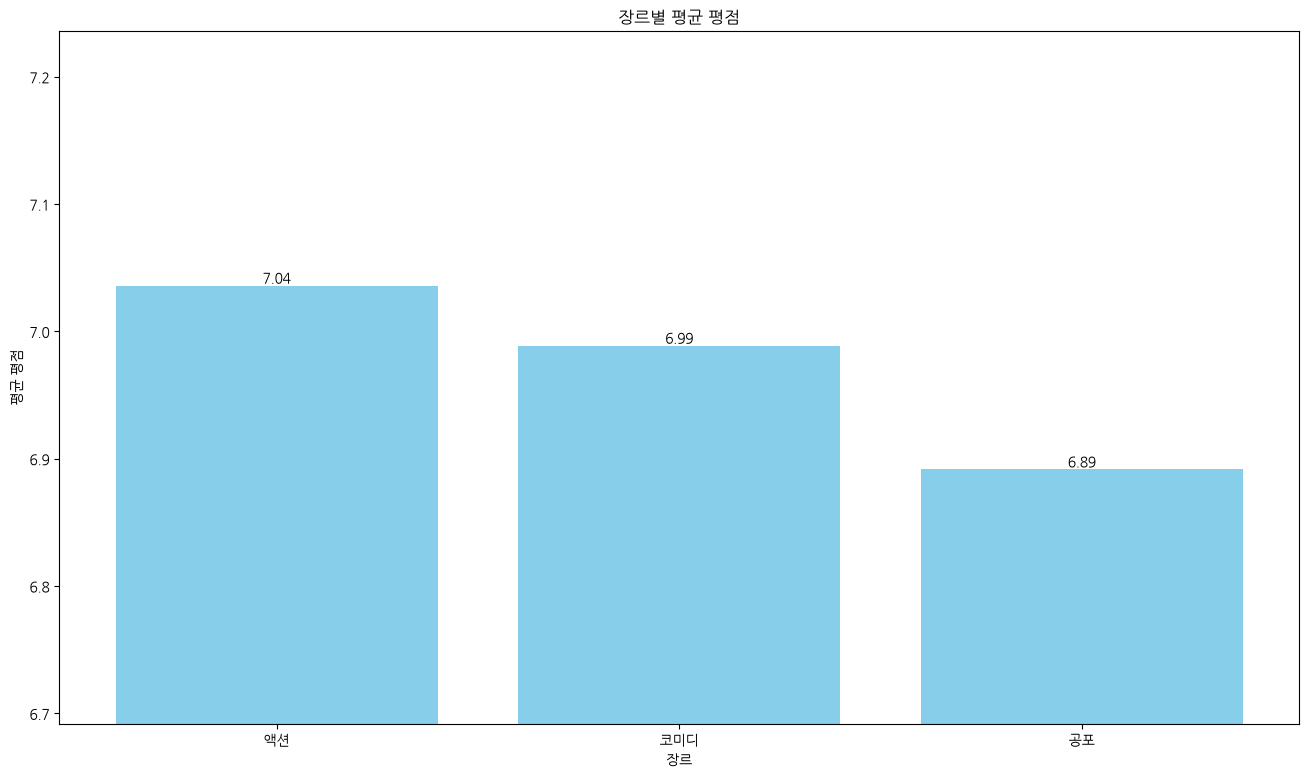

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='NanumGothic')
# 윈도우즈, 맥 둘다 나눔고딕은 있다고 함.
mpl.rc('axes', unicode_minus=False)
def genre_rating(selected_genres):
    filtered = db_df[db_df["GENRE_NAME"].isin(selected_genres)]
    result = filtered.groupby("GENRE_NAME")["VOTE_AVERAGE"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize = (16,9))
    bars = ax.bar(result.index, result.values, color="skyblue")

    # bar로 비교하려니까 0부터 최대값을 보여줘서 변화가 미미하게 나옴.
    # set_ylim을 쓰면 근처 부분만 보여줄 수 있음.
    ax.set_ylim(result.min() -0.2, result.max() +0.2)
    ax.bar_label(bars, fmt="%.2f")

    ax.set_title("장르별 평균 평점")
    ax.set_xlabel("장르")
    ax.set_ylabel("평균 평점")
    return fig
sample = genre_rating(["공포","액션","코미디"])


In [57]:
import gradio as gr

genre_list = genres_db["GENRE_NAME"].tolist()
with gr.Blocks(title = "장르별 평균 평점 비교") as demo:
    gr.Markdown("장르별 평균 평점 조회")
## 여러개 동시에 선택하려면 CheckboxGroup을 써야한다고 함.
    genre_check = gr.CheckboxGroup(choices=genre_list, label="장르 선택(복수 선택)")
    search_btn = gr.Button("조회하기")
    plot_ouput = gr.Plot(label="장르별 평균 평점")

    search_btn.click(
        fn=genre_rating,
        inputs = genre_check,
        outputs=plot_ouput
    )
demo.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


In [58]:
demo.close()

Closing server running on port: 7865


In [59]:
demo.launch(inline=False, inbrowser=True)

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
